## Annual Streamflow Comparison — Last Station

This notebook follows the same single-model workflow style as `Single-Model-Analysis.ipynb`, but runs it on a different MESH simulation (23 stations, after 14 stations with data-quality issues have already been dropped) and focuses the analysis on **one station only — the last station in the network (`05KJ001`, Saskatchewan River at The Pas)** — aggregating the daily streamflow record up to the **annual level** before comparing observed and simulated values.

It walks through the annual-level toolkit available in `postprocessinglib`:

- `data.yearly_aggregate()` for the annual mean flow and annual volume
- the full `metrics` suite (`nse`, `kge`, `rmse`, `mae`, `lognse`, `bias`,
  `calculate_metrics`, `calculate_all_metrics`) evaluated on the annual series
- the `visuals` plotting functions (`plot`, `scatter`, `histogram`, `qqplot`,
  `flow_duration_curve`) applied at annual resolution, plus a plain bar chart
  (not in the library) for the classic observed-vs-simulated annual bar comparison.


In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
from natsort import natsorted

from postprocessinglib.evaluation import data, metrics, visuals
from postprocessinglib.utilities import _helper_functions as hlp


### 1. Load the data

The merged MESH streamflow output (`MESH_output_streamflow_yassin2025.csv`) and the station lookup table (`Stations23_updated.xlsx`, 23 stations, after the 14 "bad" stations have already been dropped) are stored alongside the other example datasets in this notebooks folder.

In [2]:
# Define the input paths and organize them
start_dates = pd.to_datetime('2005-01-01')
end_dates = pd.to_datetime('2016-12-31')

# CSV file is stored alongside the other example datasets in this notebooks folder
csv_3 = glob.glob("MESH_output_streamflow_yassin2025.csv")

# Path to station names / metadata
station_input = "Stations23_updated.xlsx"
bad_stations = ["05AC003", "05BA001", "05BG010", "05BL024", "05CB001", "05DB006", "05DC010",
                 "05EA001", "05EC005", "05EE007", "05FA001", "05FC001", "05HD039", "05KE002"]


In [3]:
# Load the Streamflow data
DATAFRAMES = data.generate_dataframes(csv_fpaths=csv_3, start_date=start_dates, drop_stations=bad_stations)

obs_df = DATAFRAMES['DF_OBSERVED']       # flat columns: QOMEAS_<station>
sim_df = DATAFRAMES['DF_SIMULATED']      # flat columns: QOSIM_<station>
merged_df = DATAFRAMES['DF_MERGED']      # MultiIndex columns: (Station#, QOMEAS/QOSIM1)

for key, value in DATAFRAMES.items():
    print(f"{key}: shape={value.shape}")


The start date for the Data is 2005-01-01
DF: shape=(4383, 46)
DF_OBSERVED: shape=(4383, 23)
DF_SIMULATED: shape=(4383, 23)
DF_MERGED: shape=(4383, 46)


### 2. Relabel the merged dataframe with real station numbers

`DF_MERGED` comes back with generic `Station1, Station2, ...` labels. We rename them to the actual
station numbers using the station lookup table, exactly as in `Single-Model-Analysis.ipynb`.

In [4]:
Stations = pd.read_excel(io=station_input, dtype={"Station Number": str})
Stations = Stations.set_index('Station Number')

# Get the unique level 1 values (e.g., ['QOMEAS', 'QOSIM1'])
level_1_values = merged_df.columns.get_level_values(1).unique()

# Repeat the index from the Stations table to match the column count
new_level_0 = np.repeat(Stations.index, len(level_1_values))

# Rebuild the MultiIndex, replacing the generic Station# labels with the real station numbers
merged_df.columns = pd.MultiIndex.from_arrays([new_level_0, merged_df.columns.get_level_values(1)])

merged_df.columns


MultiIndex([('05AA024', 'QOMEAS'),
            ('05AA024', 'QOSIM1'),
            ('05AD007', 'QOMEAS'),
            ('05AD007', 'QOSIM1'),
            ('05AG006', 'QOMEAS'),
            ('05AG006', 'QOSIM1'),
            ('05AJ001', 'QOMEAS'),
            ('05AJ001', 'QOSIM1'),
            ('05BB001', 'QOMEAS'),
            ('05BB001', 'QOSIM1'),
            ('05BH004', 'QOMEAS'),
            ('05BH004', 'QOSIM1'),
            ('05BM002', 'QOMEAS'),
            ('05BM002', 'QOSIM1'),
            ('05BM004', 'QOMEAS'),
            ('05BM004', 'QOSIM1'),
            ('05BN012', 'QOMEAS'),
            ('05BN012', 'QOSIM1'),
            ('05CA009', 'QOMEAS'),
            ('05CA009', 'QOSIM1'),
            ('05CC002', 'QOMEAS'),
            ('05CC002', 'QOSIM1'),
            ('05CE001', 'QOMEAS'),
            ('05CE001', 'QOSIM1'),
            ('05CK004', 'QOMEAS'),
            ('05CK004', 'QOSIM1'),
            ('05DC001', 'QOMEAS'),
            ('05DC001', 'QOSIM1'),
            ('05DD00

### 3. Identify the last station

The "last station" is simply the last station number in the (already filtered) station list — the last
column group in `merged_df`, which is also the last row of `Stations23_updated.xlsx` and the last column
pair in the raw CSV.

In [5]:
station_list = merged_df.columns.get_level_values(0).unique().tolist()
last_station = station_list[-1]

station_name = Stations.loc[last_station, "Station Name"] if "Station Name" in Stations.columns else last_station
print(f"Last station in the network: {last_station} ({station_name})")
print(f"Total stations analyzed:     {len(station_list)}")


Last station in the network: 05KJ001 (SASKATCHEWAN RIVER AT THE PAS)
Total stations analyzed:     23


### 4. Annual-level aggregation

Two annual series are built for the last station only, using `data.yearly_aggregate()`:

- **Annual mean flow** (`method='mean'`) — the standard mean-annual-flow (MAF) comparison, in the native
  units of the data (m3/s).
- **Annual volume** (bonus) — the daily flow is first converted to a daily volume (m3/s x 86400 s/day),
  then `data.yearly_aggregate(method='sum')` gives the total annual volume, reported in million m3 (MCM).


In [6]:
# ---- Annual mean flow (m3/s) ----
last_station_df = merged_df.loc[:, [last_station]]                 # keep MultiIndex: (station, QOMEAS/QOSIM1)
annual_mean = data.yearly_aggregate(df=last_station_df, method="mean")

# Library functions like visuals.plot() expect a datetime (or datetime-convertible) index.
# yearly_aggregate() returns a plain integer-year index, so convert it to Jan-1 datetimes.
annual_mean.index = pd.to_datetime(annual_mean.index.astype(str) + "-01-01")
annual_mean.index.name = "Year"

print("Annual mean flow (m3/s):")
print(annual_mean)


Annual mean flow (m3/s):
Station Number      05KJ001            
                     QOMEAS      QOSIM1
Year                                   
2005-01-01       959.682192  992.856661
2006-01-01       768.832877  638.786328
2007-01-01       791.008219  603.279441
2008-01-01       568.237705  537.422278
2009-01-01       443.808219  455.965714
2010-01-01       707.605479  582.126938
2011-01-01      1039.536986  764.106671
2012-01-01       762.732240  749.199611
2013-01-01       850.501370  786.614412
2014-01-01       909.293151  857.825210
2015-01-01       556.257534  594.529303
2016-01-01       746.806011  645.948365


In [7]:
# ---- Annual volume (bonus, million m3) ----
volume_df = last_station_df * 86400.0                              # m3/s -> m3/day
annual_volume_m3 = data.yearly_aggregate(df=volume_df, method="sum")
annual_volume_mcm = annual_volume_m3 / 1e6                         # m3 -> MCM

annual_volume_mcm.index = pd.to_datetime(annual_volume_mcm.index.astype(str) + "-01-01")
annual_volume_mcm.index.name = "Year"

print("Annual volume (million m3):")
print(annual_volume_mcm)


Annual volume (million m3):
Station Number     05KJ001              
                    QOMEAS        QOSIM1
Year                                    
2005-01-01      30264.5376  31310.727673
2006-01-01      24245.9136  20144.765647
2007-01-01      24945.2352  19025.020463
2008-01-01      17969.0400  16994.582231
2009-01-01      13995.9360  14379.334747
2010-01-01      22315.0464  18357.955128
2011-01-01      32782.8384  24096.867967
2012-01-01      24119.4240  23691.489777
2013-01-01      26821.4112  24806.672090
2014-01-01      28675.4688  27052.375810
2015-01-01      17542.1376  18749.076100
2016-01-01      23615.7984  20426.437570


### 5. Annual observed vs. simulated dataframes (for the metrics functions)

The `metrics` module works with a plain (non-MultiIndex) observed dataframe and simulated dataframe, so
we build annual-mean versions of `obs_df`/`sim_df` restricted to the last station. A datetime (Jan-1)
index is kept — some metric functions (e.g. `time_to_peak`, used inside `calculate_all_metrics`) assume
a datetime index even though a "time to peak within a year" is not a meaningful concept once the data
has already been aggregated to one value per year (see the caveat below).

In [8]:
annual_obs = data.yearly_aggregate(df=obs_df[[f"QOMEAS_{last_station}"]], method="mean")
annual_sim = data.yearly_aggregate(df=sim_df[[f"QOSIM_{last_station}"]], method="mean")

annual_obs.index = pd.to_datetime(annual_obs.index.astype(str) + "-01-01")
annual_sim.index = pd.to_datetime(annual_sim.index.astype(str) + "-01-01")
annual_obs.index.name = "Year"
annual_sim.index.name = "Year"

print(annual_obs)
print(annual_sim)


            QOMEAS_05KJ001
Year                      
2005-01-01      959.682192
2006-01-01      768.832877
2007-01-01      791.008219
2008-01-01      568.237705
2009-01-01      443.808219
2010-01-01      707.605479
2011-01-01     1039.536986
2012-01-01      762.732240
2013-01-01      850.501370
2014-01-01      909.293151
2015-01-01      556.257534
2016-01-01      746.806011
            QOSIM_05KJ001
Year                     
2005-01-01     992.856661
2006-01-01     638.786328
2007-01-01     603.279441
2008-01-01     537.422278
2009-01-01     455.965714
2010-01-01     582.126938
2011-01-01     764.106671
2012-01-01     749.199611
2013-01-01     786.614412
2014-01-01     857.825210
2015-01-01     594.529303
2016-01-01     645.948365


### 6. Annual-level diagnostic and comparison metrics

The comparison-metric suite, evaluated on the annual (not daily) series.

**Caveat:** `metrics.calculate_all_metrics()` is **not used here**: it also tries to compute `TTP`/`TTCoM`/`SPOD` (time-to-peak, time-to-centre-of-mass, spring-pulse-onset), which internally assume a dense daily series (>=365 rows/year) to locate the day of the peak within each year. With only one row per year (annual data) that indexing goes out of bounds and the call raises an `IndexError`. `calculate_metrics()` below sidesteps this by only requesting the metrics that are valid at annual resolution.

In [9]:
print("NSE  :", metrics.nse(observed=annual_obs, simulated=annual_sim).iloc[0, 0])
print("LogNSE:", metrics.lognse(observed=annual_obs, simulated=annual_sim).iloc[0, 0])
print("RMSE :", metrics.rmse(observed=annual_obs, simulated=annual_sim).iloc[0, 0])
print("MAE  :", metrics.mae(observed=annual_obs, simulated=annual_sim).iloc[0, 0])
print("BIAS (%):", metrics.bias(observed=annual_obs, simulated=annual_sim).iloc[0, 0])


NSE  : 0.5025
LogNSE: 0.5785
RMSE : 117.1
MAE  : 88.57
BIAS (%): -9.838


In [10]:
kge_annual = metrics.kge(observed=annual_obs, simulated=annual_sim, return_kge_components=True)
kge_annual.index = [last_station]
kge_annual.index.name = "Station Number"
print("Annual KGE (with r, alpha, beta components):")
kge_annual


Annual KGE (with r, alpha, beta components):


metric,KGE,r,alpha,beta
model,model1,model1,model1,model1
Station Number,,,,
05KJ001,0.7699,0.8399,0.8672,0.9016


In [11]:
annual_metrics = metrics.calculate_metrics(
    observed=annual_obs, simulated=annual_sim,
    metrices=["RMSE", "MAE", "NSE", "LogNSE", "KGE", "BIAS"],
    metric_options={"KGE": {"return_kge_components": True}},
)
annual_metrics.index = [last_station]
annual_metrics.index.name = "Station Number"
annual_metrics


metric,RMSE,MAE,NSE,LOGNSE,KGE,r,alpha,beta,BIAS
model,model1,model1,model1,model1,model1,model1,model1,model1,model1
Station Number,,,,,,,,,
05KJ001,117.1,88.57,0.5025,0.5785,0.7699,0.8399,0.8672,0.9016,-9.838


### 7. Visualizations

#### 7a. Annual bar chart (observed vs. simulated mean annual flow)

The library has no bar-chart function, so this one panel is plain matplotlib — everything else below
uses `postprocessinglib.evaluation.visuals`.

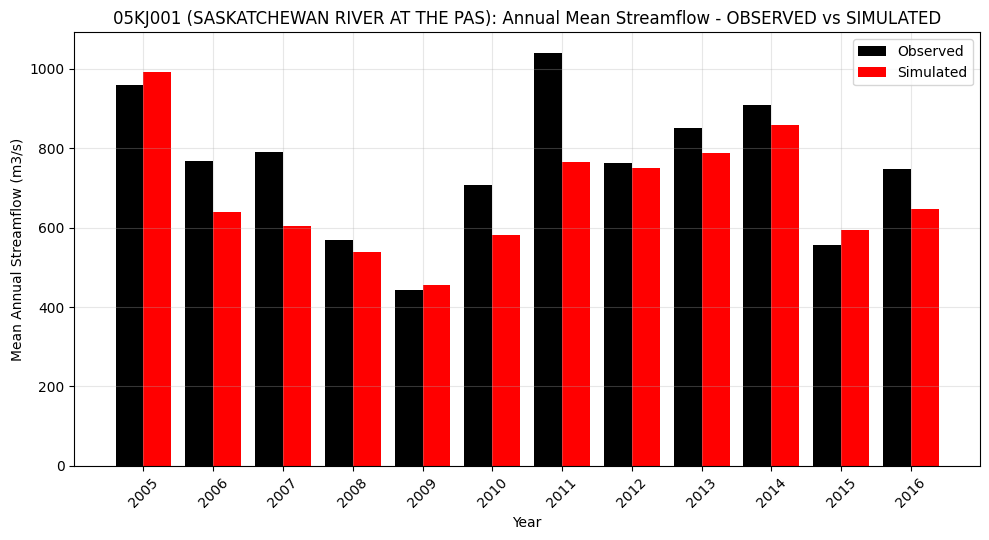

In [12]:
years = annual_mean.index.year
obs_vals = annual_mean[(last_station, "QOMEAS")]
sim_vals = annual_mean[(last_station, "QOSIM1")]

width = 0.4
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.bar(years - width/2, obs_vals, width=width, label="Observed", color="black")
ax.bar(years + width/2, sim_vals, width=width, label="Simulated", color="red")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Annual Streamflow (m3/s)")
ax.set_title(f"{last_station} ({station_name}): Annual Mean Streamflow - OBSERVED vs SIMULATED", fontsize=12)
ax.set_xticks(years)
ax.tick_params(axis='x', rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()


#### 7b. Annual trend line plot — `visuals.plot`

Number of simulated data columns: 1


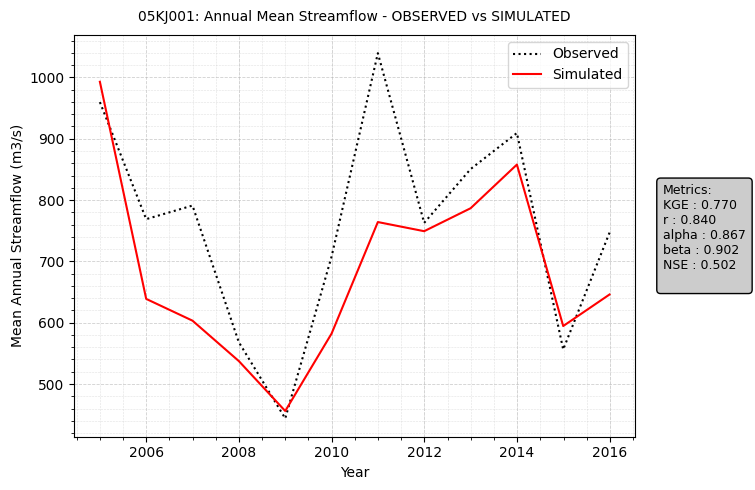

In [13]:
visuals.plot(
    merged_df=annual_mean,
    title=f"{last_station}: Annual Mean Streamflow - OBSERVED vs SIMULATED",
    labels=['Year', 'Mean Annual Streamflow (m3/s)'],
    legend=["Observed", "Simulated"],
    linestyles=('k:', 'r-'),
    linewidth=(1.5, 1.5),
    metrices=["KGE", "NSE"],
    metric_options={"KGE": {"return_kge_components": True}},
    components=("KGE", "r", "alpha", "beta"),
    grid=True, minor_grid=True,
    fig_size=(8, 5), font_size=10, text_size=9,
)


#### 7c. Annual scatter plot — `visuals.scatter`

Number of simulated data columns: 1


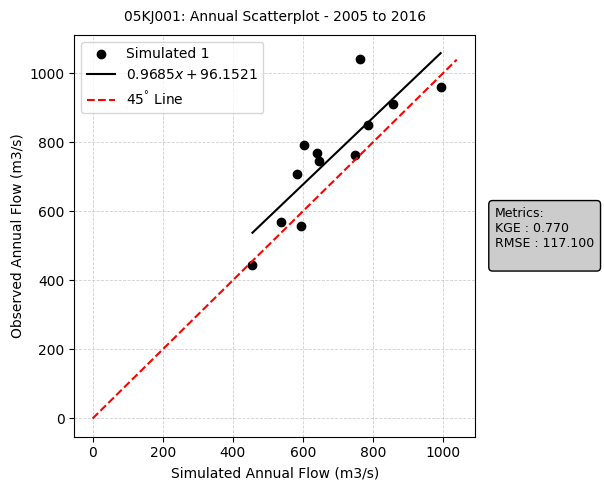

In [14]:
visuals.scatter(
    merged_df=annual_mean,
    labels=("Simulated Annual Flow (m3/s)", "Observed Annual Flow (m3/s)"),
    title=f"{last_station}: Annual Scatterplot - {years.min()} to {years.max()}",
    grid=True,
    markerstyle=['ko'],
    line45=True,
    best_fit=True,
    metrices=['KGE', 'RMSE'],
    fig_size=(6, 5), font_size=10, text_size=9,
)


#### 7d. Annual flow distribution — `visuals.histogram`

Only ~12 annual values are available, so the bin count is kept small.

Number of simulated data columns: 1


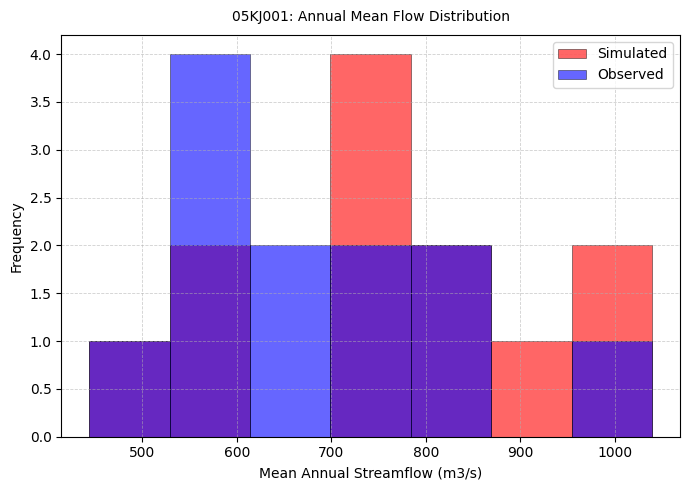

In [15]:
visuals.histogram(
    merged_df=annual_mean,
    bins=8,
    title=f"{last_station}: Annual Mean Flow Distribution",
    labels=('Mean Annual Streamflow (m3/s)', 'Frequency'),
    legend=('Simulated', 'Observed'),
    grid=True,
    fig_size=(7, 5), font_size=10,
)


#### 7e. Annual Q-Q plot — `visuals.qqplot`

Number of simulated data columns: 1


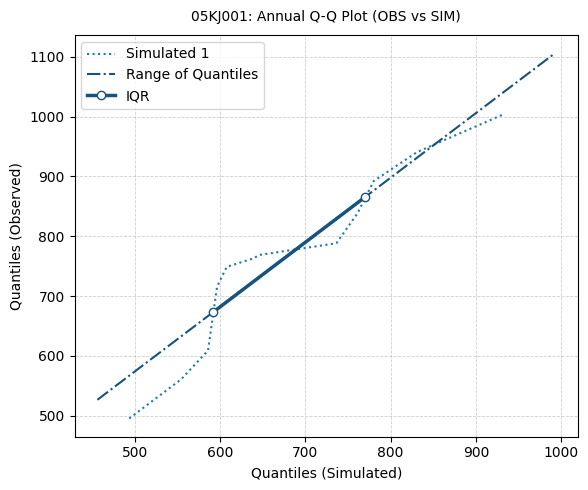

In [16]:
visuals.qqplot(
    merged_df=annual_mean,
    labels=("Quantiles (Simulated)", "Quantiles (Observed)"),
    title=f"{last_station}: Annual Q-Q Plot (OBS vs SIM)",
    grid=True,
    fig_size=(6, 5), font_size=10,
)


#### 7f. Annual flow duration curve — `visuals.flow_duration_curve` (bonus)

Flow-duration curves are normally built from daily data; applying it to just ~12 annual points is
unconventional, but the function is generic and it is included here for completeness since the goal was
to exercise the full toolkit.

Number of simulated data columns: 1
Number of linewidths provided is less than the number of columns. Number of columns : 2. Number of linewidths provided is:  1. Defaulting to 1.5
Number of linestyles provided is less than the number of columns. Number of columns : 2. Number of linestyles provided is:  1. Defaulting to solid lines (-)


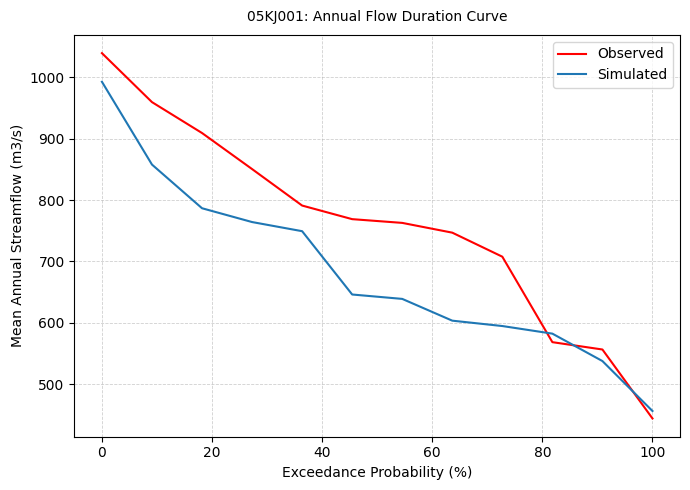

In [17]:
visuals.flow_duration_curve(
    merged_df=annual_mean,
    legend=("Observed", "Simulated"),
    title=f"{last_station}: Annual Flow Duration Curve",
    labels=('Exceedance Probability (%)', 'Mean Annual Streamflow (m3/s)'),
    grid=True,
    fig_size=(7, 5), font_size=10,
)


### 8. Annual comparison table

In [18]:
annual_table = pd.DataFrame({
    "Observed (m3/s)": obs_vals.values,
    "Simulated (m3/s)": sim_vals.values,
    "Observed Volume (MCM)": annual_volume_mcm[(last_station, "QOMEAS")].values,
    "Simulated Volume (MCM)": annual_volume_mcm[(last_station, "QOSIM1")].values,
}, index=years)
annual_table.index.name = "Year"
annual_table


,Observed (m3/s),Simulated (m3/s),Observed Volume (MCM),Simulated Volume (MCM)
Year,,,,
2005,959.682192,992.856661,30264.5376,31310.727673
2006,768.832877,638.786328,24245.9136,20144.765647
2007,791.008219,603.279441,24945.2352,19025.020463
2008,568.237705,537.422278,17969.0400,16994.582231
2009,443.808219,455.965714,13995.9360,14379.334747
2010,707.605479,582.126938,22315.0464,18357.955128
2011,1039.536986,764.106671,32782.8384,24096.867967
2012,762.732240,749.199611,24119.4240,23691.489777
2013,850.501370,786.614412,26821.4112,24806.672090
